In [2]:
!pip install scikit-learn matplotlib pandas numpy seaborn shap xgboost requests

In [3]:
import requests, zipfile, io
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
# Chargement depuis UCI ML Repository (archive officielle)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00331/sentiment%20labelled%20sentences.zip"
r = requests.get(url, timeout=30)
z = zipfile.ZipFile(io.BytesIO(r.content))
# Extraction des avis Amazon (également disponibles : yelp, imdb)
with z.open('sentiment labelled sentences/amazon_cells_labelled.txt') as f:
  df = pd.read_csv(f, sep='\t', header=None, names=['avis', 'sentiment'])
print(f"Forme : {df.shape}")
print(f"Distribution : {df['sentiment'].value_counts().to_dict()}")
print(f"\nExemples :")
print(df.sample(3, random_state=42))
# Feature engineering NLP : TF-IDF (unigrammes + bigrammes)
vectorizer = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1, 2))
X = vectorizer.fit_transform(df['avis']) # Sparse matrix
y = df['sentiment']
feature_names = list(vectorizer.get_feature_names_out())
print(f"\nVocabulaire TF-IDF : {len(feature_names)} tokens")
# Split stratifié
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
# TF-IDF est déjà normalisé — pas de StandardScaler
X_train_sc = X_train
X_test_sc = X_test
print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")

Forme : (1000, 2)
Distribution : {0: 500, 1: 500}

Exemples :
                                                  avis  sentiment
521  Thanks again to Amazon for having the things I...          1
737  The tracfonewebsite is user friendly and makes...          1
740             I would highly recommend this product.          1

Vocabulaire TF-IDF : 500 tokens
Train : 800 | Test : 200


Logistic Regression    → Accuracy : 76.5% | F1-macro : 0.765 | F1-weighted : 0.765
Random Forest          → Accuracy : 75.5% | F1-macro : 0.755 | F1-weighted : 0.755
XGBoost                → Accuracy : 69.5% | F1-macro : 0.695 | F1-weighted : 0.695

=== TABLEAU COMPARATIF ===
                     accuracy  f1_macro  f1_weighted
Logistic Regression     0.765     0.765        0.765
Random Forest           0.755     0.755        0.755
XGBoost                 0.695     0.695        0.695


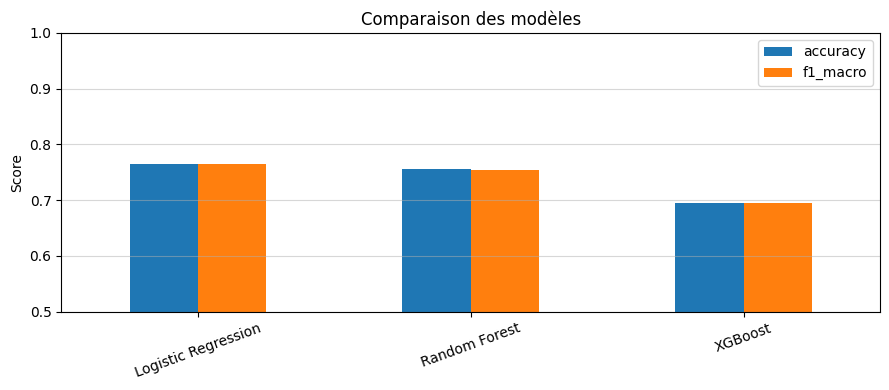

In [4]:
import matplotlib.pyplot as plt # Nécessaire pour tous les cas (A, B et C)
import seaborn as sns # Nécessaire pour tous les cas (A, B et C)
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
# Les trois modèles imposés par le TP
modeles = {
"Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
"Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
"XGBoost": XGBClassifier(
n_estimators=100, random_state=42,
eval_metric='logloss', verbosity=0
),
}
resultats = {}
for nom, modele in modeles.items():
  modele.fit(X_train_sc, y_train)
  pred = modele.predict(X_test_sc)
  acc = accuracy_score(y_test, pred)
  f1_mac = f1_score(y_test, pred, average='macro')
  f1_wei = f1_score(y_test, pred, average='weighted')
  resultats[nom] = {'accuracy': acc, 'f1_macro': f1_mac, 'f1_weighted': f1_wei}
  print(f"{nom:22s} → Accuracy : {acc*100:.1f}% | F1-macro : {f1_mac:.3f} | F1-weighted : {f1_wei:.3f}")
# Tableau comparatif
df_resultats = pd.DataFrame(resultats).T
print("\n=== TABLEAU COMPARATIF ===")
print(df_resultats.round(3))
# Visualisation
df_resultats[['accuracy', 'f1_macro']].plot(kind='bar', figsize=(9, 4))
plt.title('Comparaison des modèles')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.ylim(0.5, 1.0)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('comparaison_modeles.png')
plt.show()

=== RAPPORT DÉTAILLÉ — XGBoost ===
              precision    recall  f1-score   support

           0       0.69      0.70      0.70       100
           1       0.70      0.69      0.69       100

    accuracy                           0.69       200
   macro avg       0.70      0.69      0.69       200
weighted avg       0.70      0.69      0.69       200



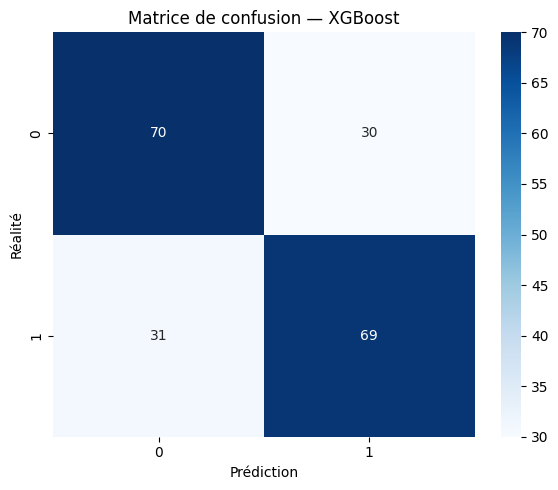

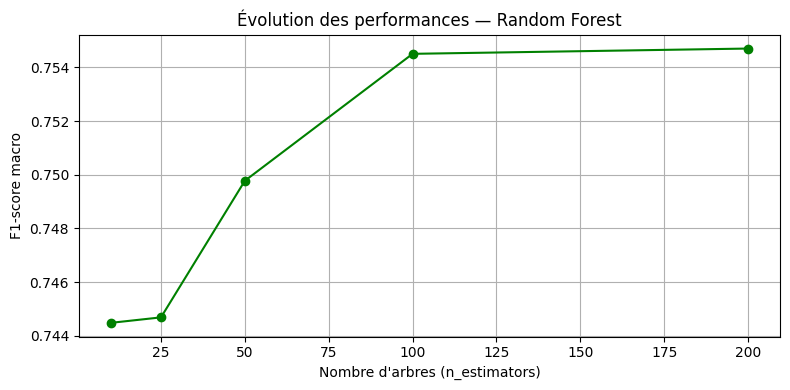

In [5]:
from sklearn.metrics import confusion_matrix, classification_report
# Choisir le meilleur modèle selon votre tableau comparatif
# Remplacez "XGBoost" par le nom du modèle que vous avez identifié
NOM_MEILLEUR = "XGBoost"
meilleur = modeles[NOM_MEILLEUR]
y_pred = meilleur.predict(X_test_sc)
# Rapport complet
print(f"=== RAPPORT DÉTAILLÉ — {NOM_MEILLEUR} ===")
print(classification_report(y_test, y_pred))
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matrice de confusion — {NOM_MEILLEUR}')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
# Évolution de Random Forest selon le nombre d'arbres
n_estimators_range = [10, 25, 50, 100, 200]
scores_rf = []
for n in n_estimators_range:
  rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
  rf_temp.fit(X_train_sc, y_train)
  pred_temp = rf_temp.predict(X_test_sc)
  scores_rf.append(f1_score(y_test, pred_temp, average='macro'))
plt.figure(figsize=(8, 4))
plt.plot(n_estimators_range, scores_rf, 'g-o')
plt.xlabel("Nombre d'arbres (n_estimators)")
plt.ylabel("F1-score macro")
plt.title("Évolution des performances — Random Forest")
plt.grid(True)
plt.tight_layout()
plt.savefig('rf_evolution.png')
plt.show()

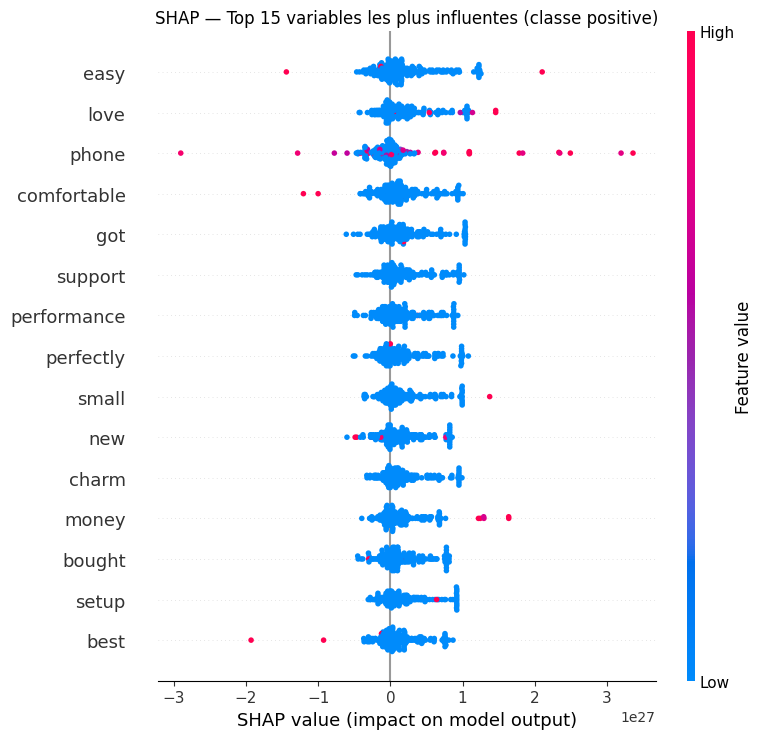

In [8]:
import shap
import scipy.sparse as sp
# SHAP avec le Random Forest (TreeExplainer, rapide sur forêts)
rf_model = modeles["Random Forest"]
# Convertir en dense si sparse (Cas B — TF-IDF)
# Limiter à 200 exemples pour la rapidité
X_sample = X_test_sc[:200]
if sp.issparse(X_sample):
  X_sample = X_sample.toarray()
else:
  X_sample = np.array(X_sample)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample, check_additivity=False)
# Compatibilité SHAP < 0.42 (liste) et SHAP >= 0.42 (tableau 3D ou 2D)
# Classification binaire : on cible la classe positive
if isinstance(shap_values, list):
  sv = shap_values[1]
elif len(shap_values.shape) == 3:
  sv = shap_values[:, :, 1]
else:
  sv = shap_values
# Summary plot : top 15 variables les plus influentes
plt.figure()
shap.summary_plot(
sv, X_sample,
feature_names=feature_names,
max_display=15,
show=False
# SHAP < 0.42 : liste [classe_0, classe_1]
# SHAP >= 0.42 : tableau (n, features, classes)
# Déjà 2D (cas binaire simplifié)
# Limiter l'affichage (utile pour NLP)
)
plt.title("SHAP — Top 15 variables les plus influentes (classe positive)")
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()